# Fine-Tune `yolo_hands_seconds.pt` On `data/from_internet`

This notebook does all steps in one place:

- Builds a YOLO-seg dataset from `analog_clock/data/from_internet`.
- Uses only images that have matching JSON annotations from the tagging platform.
- Evaluates the baseline model (`yolo_hands_seconds.pt`) on a held-out test split.
- Fine-tunes the model on train/val.
- Evaluates again on the same test split and shows before/after predictions.


In [10]:
from __future__ import annotations

import json
import random
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from ultralytics import YOLO

SUPPORTED_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"}
CLASS_NAMES = ["hour_hand", "minute_hand", "second_hand"]


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "analog_clock").exists() and (p / "digital_clock").exists():
            return p
    raise FileNotFoundError("Could not locate repository root from current working directory")


REPO_ROOT = find_repo_root()
SOURCE_DIR = REPO_ROOT / "analog_clock" / "data" / "from_internet_cropped"
BASE_MODEL_PATH = REPO_ROOT / "analog_clock" / "yolo_detetct_hands" / "yolo_hands_seconds.pt"

WORK_DIR = REPO_ROOT / "ac_hands_ft_cropped"
DATASET_DIR = WORK_DIR / "dataset"
RUNS_DIR = WORK_DIR / "runs"

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
SPLIT_SEED = 42

EPOCHS = 40
IMG_SIZE = 640
BATCH_SIZE_GPU = 16
RUN_NAME = "yolo_hands_seconds_finetune_from_internet"

GPU_INDEX = 0
REQUIRE_CUDA = True

assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-6
assert SOURCE_DIR.exists(), (
    f"Missing source dir: {SOURCE_DIR}. "
    "Generate it first with: "
    "python analog_clock/yolo_detetct_hands/crop_with_clock_detector/crop_and_remap_annotations.py --overwrite"
)
assert BASE_MODEL_PATH.exists(), f"Missing base model: {BASE_MODEL_PATH}"

if REQUIRE_CUDA and not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU is required for this notebook but this kernel is using CPU-only PyTorch.\n"
    )

DEVICE = GPU_INDEX
BATCH_SIZE = BATCH_SIZE_GPU
DEVICE_NAME = torch.cuda.get_device_name(GPU_INDEX)

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"SOURCE_DIR: {SOURCE_DIR}")
print(f"BASE_MODEL_PATH: {BASE_MODEL_PATH}")
print(f"DEVICE: cuda:{DEVICE} ({DEVICE_NAME}) | BATCH_SIZE: {BATCH_SIZE}")


REPO_ROOT: C:\Users\danie\Desktop\DS\Degree\projects\Advanced_topics_in_DS\Clock-Recognition-And-Manipulation-DL
SOURCE_DIR: C:\Users\danie\Desktop\DS\Degree\projects\Advanced_topics_in_DS\Clock-Recognition-And-Manipulation-DL\analog_clock\data\from_internet_cropped
BASE_MODEL_PATH: C:\Users\danie\Desktop\DS\Degree\projects\Advanced_topics_in_DS\Clock-Recognition-And-Manipulation-DL\analog_clock\yolo_detetct_hands\yolo_hands_seconds.pt
DEVICE: cuda:0 (NVIDIA GeForce RTX 3050 OEM) | BATCH_SIZE: 16


In [11]:
@dataclass
class Record:
    image_path: Path
    ann_path: Path
    yolo_lines: list[str]


def _find_sidecar_for_image(image_path: Path) -> Path | None:
    candidates = [
        image_path.with_suffix(".ann.json"),
        image_path.with_suffix(".json"),
    ]
    for p in candidates:
        if p.exists() and p.is_file():
            return p
    return None


def _load_normalized_annotations(payload: dict[str, Any]) -> dict[int, list[tuple[float, float]]]:
    out: dict[int, list[tuple[float, float]]] = {}
    ann_obj = payload.get("annotations", {})
    if not isinstance(ann_obj, dict):
        return out

    for cls_key, points in ann_obj.items():
        try:
            cls_id = int(cls_key)
        except (TypeError, ValueError):
            continue
        if cls_id < 0 or cls_id > 2:
            continue
        if not isinstance(points, list):
            continue

        cleaned: list[tuple[float, float]] = []
        for pt in points:
            if not isinstance(pt, (list, tuple)) or len(pt) < 2:
                continue
            try:
                x = float(pt[0])
                y = float(pt[1])
            except (TypeError, ValueError):
                continue
            if np.isnan(x) or np.isnan(y):
                continue
            cleaned.append((max(0.0, min(1.0, x)), max(0.0, min(1.0, y))))

        if len(cleaned) >= 3:
            out[cls_id] = cleaned

    return out


def _to_yolo_lines(annotations: dict[int, list[tuple[float, float]]]) -> list[str]:
    lines: list[str] = []
    for cls_id in sorted(annotations.keys()):
        pts = annotations[cls_id]
        if len(pts) < 3:
            continue
        coords = " ".join(f"{x:.6f} {y:.6f}" for x, y in pts)
        lines.append(f"{cls_id} {coords}")
    return lines


def collect_records_from_sidecars(source_dir: Path) -> tuple[list[Record], list[Path], list[Path]]:
    image_paths = sorted(
        [
            p for p in source_dir.iterdir()
            if p.is_file() and p.suffix.lower() in SUPPORTED_IMAGE_EXTS
        ]
    )

    records: list[Record] = []
    invalid_ann: list[Path] = []
    images_without_json: list[Path] = []

    for image_path in image_paths:
        ann_path = _find_sidecar_for_image(image_path)
        if ann_path is None:
            images_without_json.append(image_path)
            continue

        try:
            payload = json.loads(ann_path.read_text(encoding="utf-8"))
        except Exception:
            invalid_ann.append(ann_path)
            continue

        anns = _load_normalized_annotations(payload)
        lines = _to_yolo_lines(anns)
        if not lines:
            invalid_ann.append(ann_path)
            continue

        records.append(Record(image_path=image_path, ann_path=ann_path, yolo_lines=lines))

    return records, invalid_ann, images_without_json


def split_records(records: list[Record], train_ratio: float, val_ratio: float, seed: int = 42) -> dict[str, list[Record]]:
    if not records:
        raise RuntimeError("No valid records to split")

    rng = random.Random(seed)
    shuffled = records.copy()
    rng.shuffle(shuffled)

    n = len(shuffled)
    n_train = max(1, int(n * train_ratio))
    n_val = max(1, int(n * val_ratio))
    if n_train + n_val >= n:
        n_val = max(1, n - n_train - 1)
    n_test = n - n_train - n_val
    if n_test <= 0:
        n_test = 1
        if n_train > n_val:
            n_train -= 1
        else:
            n_val -= 1

    train = shuffled[:n_train]
    val = shuffled[n_train:n_train + n_val]
    test = shuffled[n_train + n_val:]
    return {"train": train, "val": val, "test": test}


def build_yolo_dataset(source_dir: Path, dataset_dir: Path, train_ratio: float, val_ratio: float, seed: int = 42):
    records, invalid_ann, images_without_json = collect_records_from_sidecars(source_dir)
    splits = split_records(records, train_ratio=train_ratio, val_ratio=val_ratio, seed=seed)

    if dataset_dir.exists():
        shutil.rmtree(dataset_dir)

    for split in ["train", "val", "test"]:
        (dataset_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (dataset_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

    filename_mappings: list[dict[str, str]] = []
    for split, items in splits.items():
        for idx, rec in enumerate(items):
            dst_stem = f"{split}_{idx:05d}"
            dst_img_name = f"{dst_stem}{rec.image_path.suffix.lower()}"
            dst_img = dataset_dir / "images" / split / dst_img_name
            dst_lbl = dataset_dir / "labels" / split / f"{dst_stem}.txt"
            shutil.copy2(rec.image_path, dst_img)
            dst_lbl.write_text("\n".join(rec.yolo_lines) + "\n", encoding="utf-8")
            filename_mappings.append(
                {
                    "split": split,
                    "source_image": str(rec.image_path),
                    "source_annotation": str(rec.ann_path),
                    "dataset_image": str(dst_img),
                    "dataset_label": str(dst_lbl),
                }
            )

    mapping_csv_path = dataset_dir / "filename_mapping.csv"
    pd.DataFrame(filename_mappings).to_csv(mapping_csv_path, index=False)

    data_yaml = {
        "path": str(dataset_dir.resolve()),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "nc": 3,
        "names": CLASS_NAMES,
    }
    yaml_path = dataset_dir / "data.yaml"
    yaml_path.write_text(yaml.safe_dump(data_yaml, sort_keys=False), encoding="utf-8")

    report = {
        "records_total": len(records),
        "invalid_or_empty_annotations": len(invalid_ann),
        "images_without_matching_json": len(images_without_json),
        "train": len(splits["train"]),
        "val": len(splits["val"]),
        "test": len(splits["test"]),
        "yaml_path": str(yaml_path),
        "mapping_csv": str(mapping_csv_path),
    }
    return report, splits, invalid_ann, images_without_json


def extract_metrics(val_result) -> dict[str, float]:
    out: dict[str, float] = {}
    raw = getattr(val_result, "results_dict", {}) or {}

    key_map = {
        "metrics/mAP50(B)": "box_map50",
        "metrics/mAP50-95(B)": "box_map50_95",
        "metrics/mAP50(M)": "seg_map50",
        "metrics/mAP50-95(M)": "seg_map50_95",
        "metrics/precision(B)": "box_precision",
        "metrics/recall(B)": "box_recall",
        "metrics/precision(M)": "seg_precision",
        "metrics/recall(M)": "seg_recall",
        "fitness": "fitness",
    }
    for raw_key, norm_key in key_map.items():
        if raw_key in raw:
            out[norm_key] = float(raw[raw_key])

    box = getattr(val_result, "box", None)
    seg = getattr(val_result, "seg", None)

    if box is not None:
        out.setdefault("box_map50", float(getattr(box, "map50", np.nan)))
        out.setdefault("box_map50_95", float(getattr(box, "map", np.nan)))
    if seg is not None:
        out.setdefault("seg_map50", float(getattr(seg, "map50", np.nan)))
        out.setdefault("seg_map50_95", float(getattr(seg, "map", np.nan)))

    return out


def show_predictions(base_model: YOLO, tuned_model: YOLO, image_paths: list[Path], conf: float = 0.25):
    if not image_paths:
        print("No test images to visualize")
        return

    for image_path in image_paths:
        src_bgr = cv2.imread(str(image_path))
        if src_bgr is None:
            continue

        base_pred = base_model.predict(source=str(image_path), imgsz=IMG_SIZE, conf=conf, device=DEVICE, verbose=False)[0]
        tuned_pred = tuned_model.predict(source=str(image_path), imgsz=IMG_SIZE, conf=conf, device=DEVICE, verbose=False)[0]

        src_rgb = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2RGB)
        base_rgb = cv2.cvtColor(base_pred.plot(), cv2.COLOR_BGR2RGB)
        tuned_rgb = cv2.cvtColor(tuned_pred.plot(), cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        axes[0].imshow(src_rgb)
        axes[0].set_title("Original")
        axes[0].axis("off")
        axes[1].imshow(base_rgb)
        axes[1].set_title("Baseline")
        axes[1].axis("off")
        axes[2].imshow(tuned_rgb)
        axes[2].set_title("Fine-tuned")
        axes[2].axis("off")
        plt.suptitle(image_path.name)
        plt.tight_layout()
        plt.show()


In [12]:
DATASET_REPORT, SPLITS, INVALID_ANN, IMAGES_WITHOUT_JSON = build_yolo_dataset(
    source_dir=SOURCE_DIR,
    dataset_dir=DATASET_DIR,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    seed=SPLIT_SEED,
)

DATA_YAML_PATH = DATASET_DIR / "data.yaml"
print("Dataset created")
for k, v in DATASET_REPORT.items():
    print(f"  {k}: {v}")

if INVALID_ANN:
    print("\nFirst invalid/empty annotation files:")
    for p in INVALID_ANN[:10]:
        print(f"  - {p.name}")

if IMAGES_WITHOUT_JSON:
    print("\nFirst images skipped (no same-name json):")
    for p in IMAGES_WITHOUT_JSON[:10]:
        print(f"  - {p.name}")


Dataset created
  records_total: 103
  invalid_or_empty_annotations: 0
  images_without_matching_json: 0
  train: 72
  val: 15
  test: 16
  yaml_path: C:\Users\danie\Desktop\DS\Degree\projects\Advanced_topics_in_DS\Clock-Recognition-And-Manipulation-DL\ac_hands_ft_cropped\dataset\data.yaml
  mapping_csv: C:\Users\danie\Desktop\DS\Degree\projects\Advanced_topics_in_DS\Clock-Recognition-And-Manipulation-DL\ac_hands_ft_cropped\dataset\filename_mapping.csv


In [13]:
base_model = YOLO(str(BASE_MODEL_PATH))
baseline_val = base_model.val(
    data=str(DATA_YAML_PATH),
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,
    verbose=False,
)
baseline_metrics = extract_metrics(baseline_val)

print("Baseline metrics on test split")
for k in sorted(baseline_metrics.keys()):
    print(f"  {k}: {baseline_metrics[k]:.4f}")


Ultralytics 8.4.14  Python-3.11.7 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 OEM, 8192MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,469 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 8.17.3 MB/s, size: 76.3 KB)
val: Scanning C:\Users\danie\Desktop\DS\Degree\projects\Advanced_topics_in_DS\Clock-Recognition-And-Manipulation-DL\ac_hands_ft_cropped\dataset\labels\test... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16 585.3it/s 0.0s
val: New cache created: C:\Users\danie\Desktop\DS\Degree\projects\Advanced_topics_in_DS\Clock-Recognition-And-Manipulation-DL\ac_hands_ft_cropped\dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.3it/s 0.4s
                   all         16         40      0.622      0.466      0.444      0.165     0.0812      0.108     0.0263    0.00646
Speed: 2.7ms preprocess, 14.3m

In [14]:
finetune_model = YOLO(str(BASE_MODEL_PATH))
train_result = finetune_model.train(
    data=str(DATA_YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,
    patience=15,
    optimizer="AdamW",
    lr0=1e-3,
    lrf=1e-2,
    freeze=10,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    exist_ok=True,
    seed=SPLIT_SEED,
)

TRAIN_RUN_DIR = Path(train_result.save_dir)
BEST_WEIGHTS = TRAIN_RUN_DIR / "weights" / "best.pt"
LAST_WEIGHTS = TRAIN_RUN_DIR / "weights" / "last.pt"
if not BEST_WEIGHTS.exists() and LAST_WEIGHTS.exists():
    BEST_WEIGHTS = LAST_WEIGHTS

print(f"TRAIN_RUN_DIR: {TRAIN_RUN_DIR}")
print(f"BEST_WEIGHTS:  {BEST_WEIGHTS}")


Ultralytics 8.4.14  Python-3.11.7 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 OEM, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\danie\Desktop\DS\Degree\projects\Advanced_topics_in_DS\Clock-Recognition-And-Manipulation-DL\ac_hands_ft_cropped\dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\danie\Desktop\DS\Degree\projects\Advanced_topic

In [15]:
%matplotlib inline 

tuned_model = YOLO(str(BEST_WEIGHTS))
tuned_val = tuned_model.val(
    data=str(DATA_YAML_PATH),
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,
    verbose=False,
)
tuned_metrics = extract_metrics(tuned_val)

comparison = pd.DataFrame(
    {
        "baseline": baseline_metrics,
        "fine_tuned": tuned_metrics,
    }
).sort_index()
comparison["delta"] = comparison["fine_tuned"] - comparison["baseline"]

print("Before vs After on test split")
display(comparison.style.format("{:.4f}"))


Ultralytics 8.4.14  Python-3.11.7 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3050 OEM, 8192MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,469 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 767.1185.5 MB/s, size: 72.9 KB)
val: Scanning C:\Users\danie\Desktop\DS\Degree\projects\Advanced_topics_in_DS\Clock-Recognition-And-Manipulation-DL\ac_hands_ft_cropped\dataset\labels\test.cache... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.9it/s 0.3s
                   all         16         40      0.487      0.571      0.536       0.25      0.187      0.168     0.0875     0.0141
Speed: 0.6ms preprocess, 5.9ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to C:\Users\danie\Desktop\DS\Degree\projects\Advanced_topics_in_DS\Clock-Recognition-And-Manipulation-DL\

,baseline,fine_tuned,delta
box_map50,0.4441,0.5359,0.0919
box_map50_95,0.1654,0.2503,0.0849
box_precision,0.6220,0.4869,-0.1351
box_recall,0.4664,0.5708,0.1044
fitness,0.1719,0.2644,0.0925
seg_map50,0.0263,0.0875,0.0612
seg_map50_95,0.0065,0.0141,0.0076
seg_precision,0.0812,0.1867,0.1055
seg_recall,0.1083,0.1676,0.0593


Visualizing 8 test images


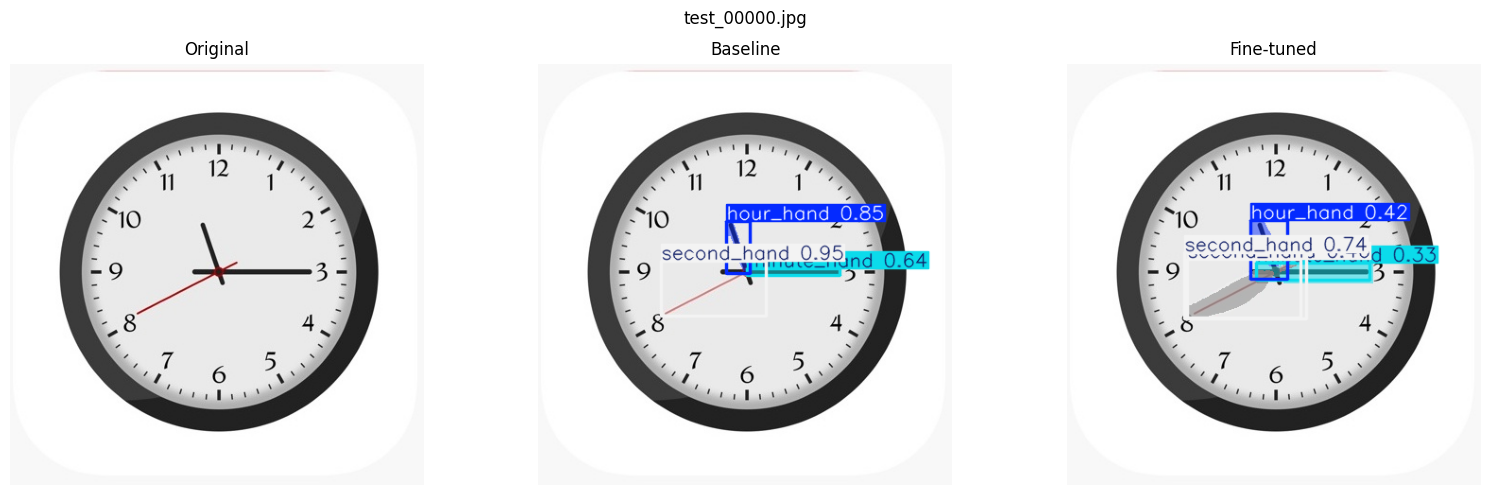

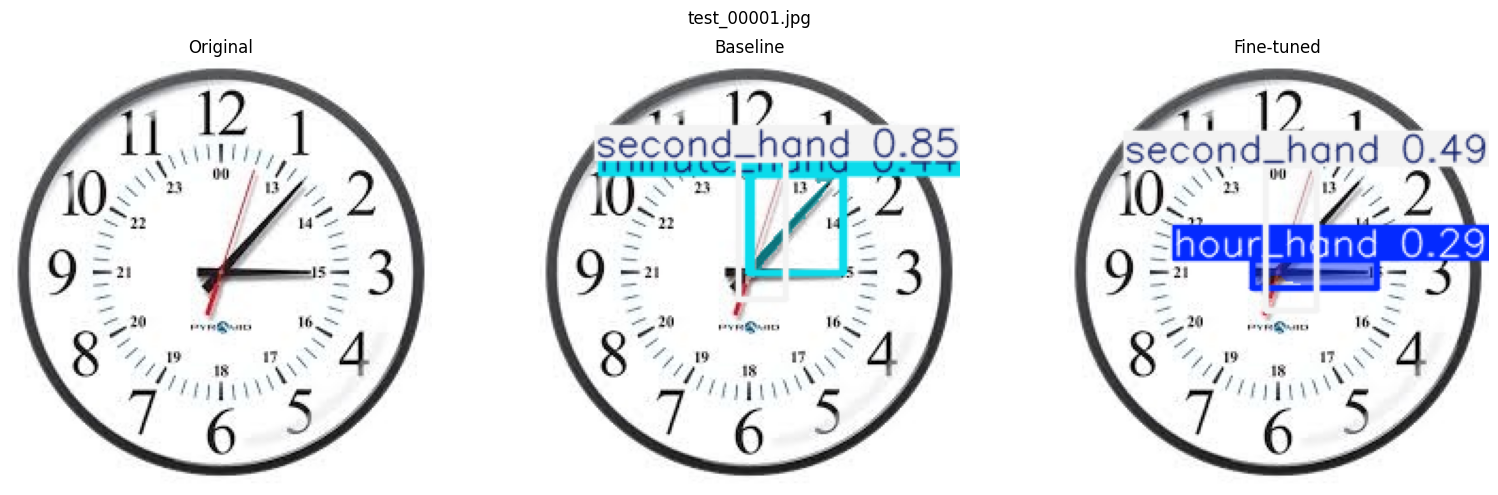

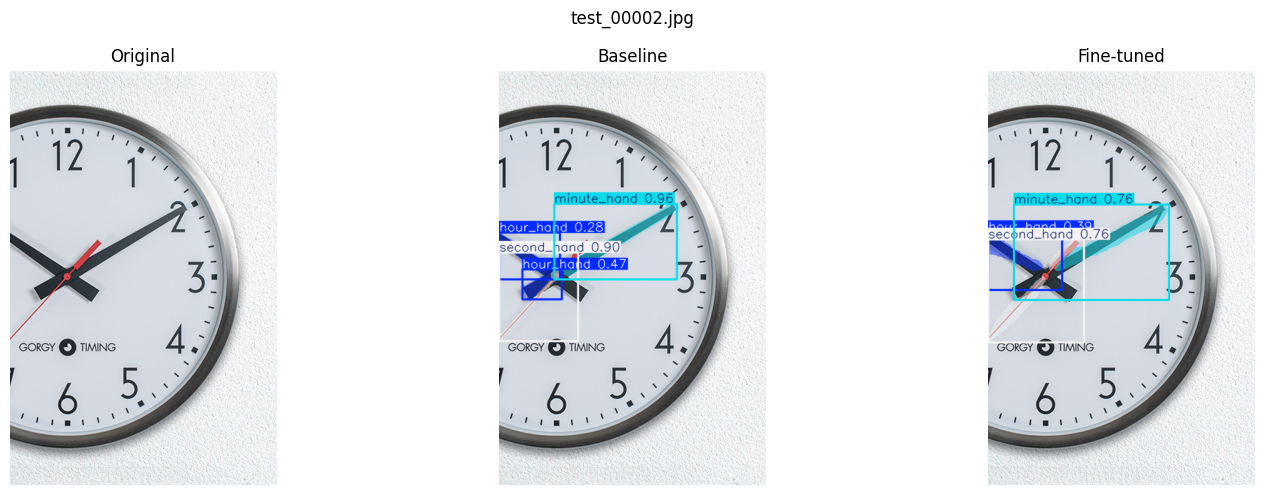

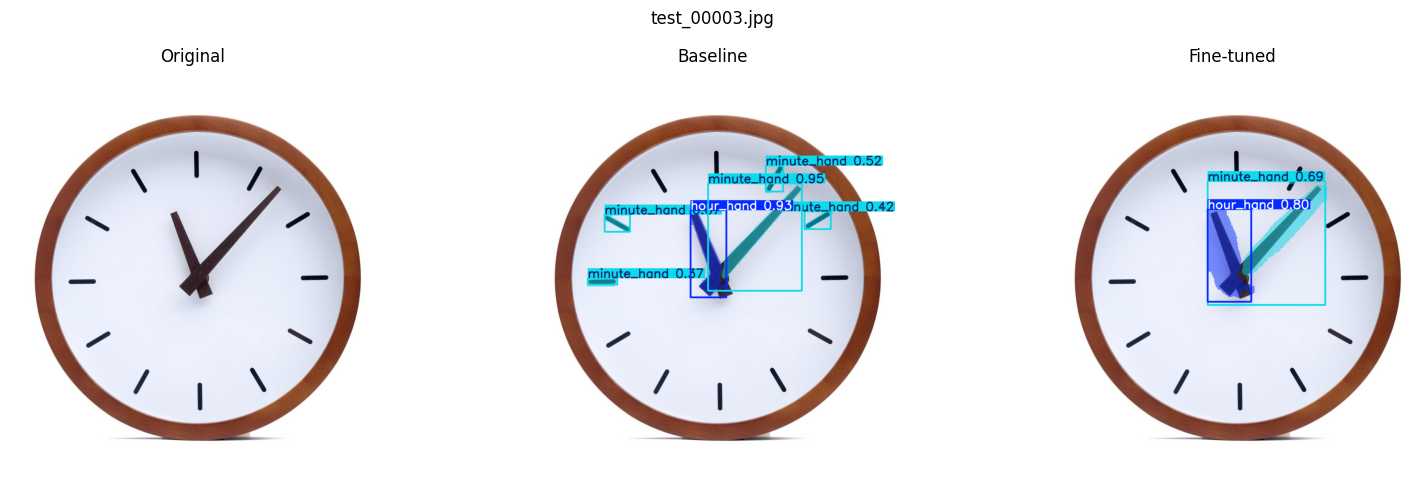

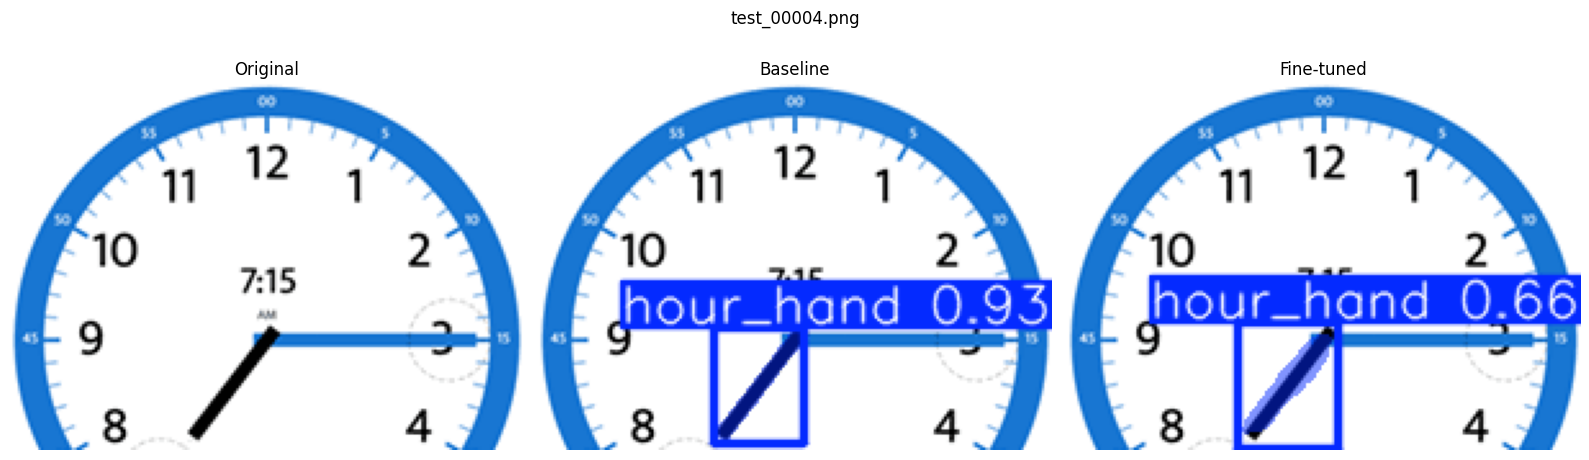

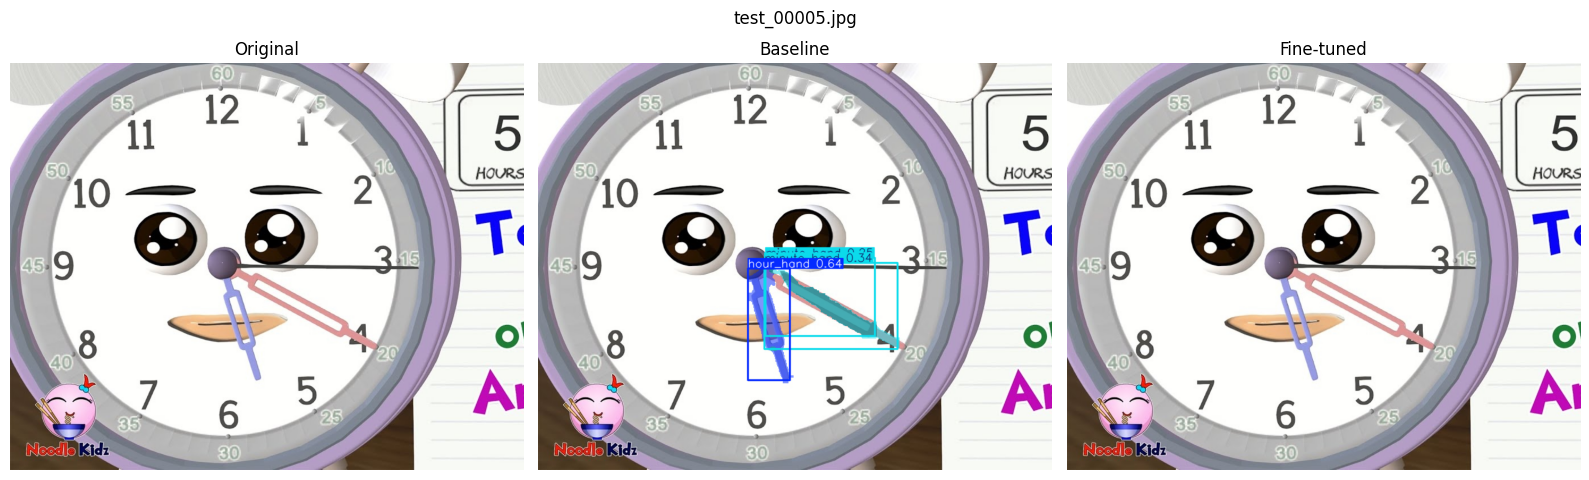

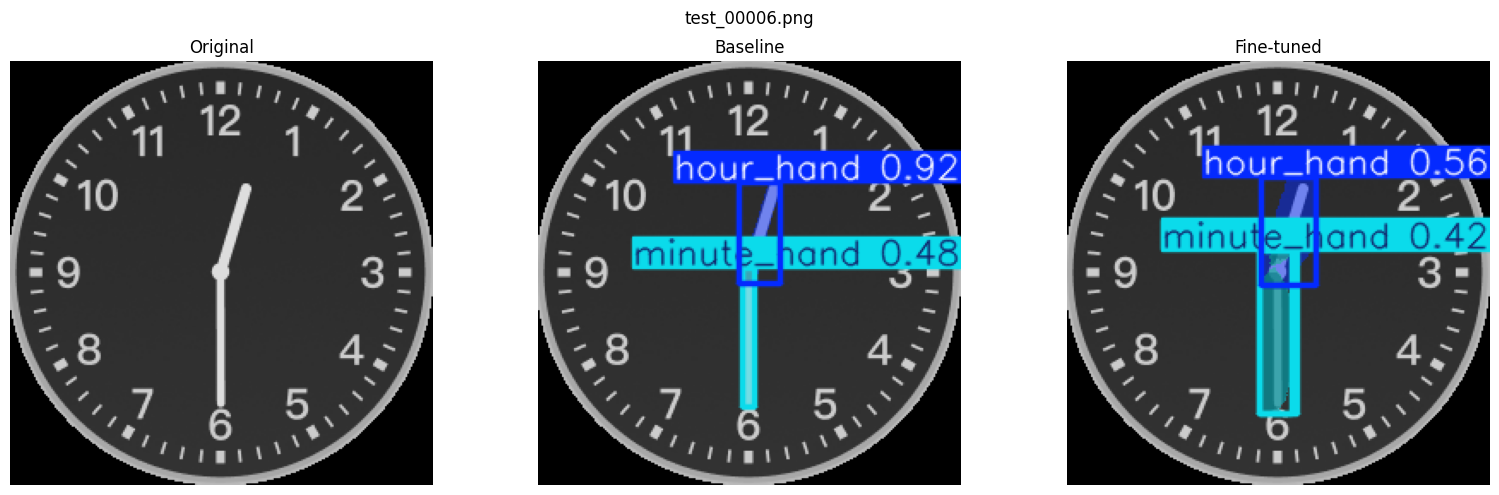

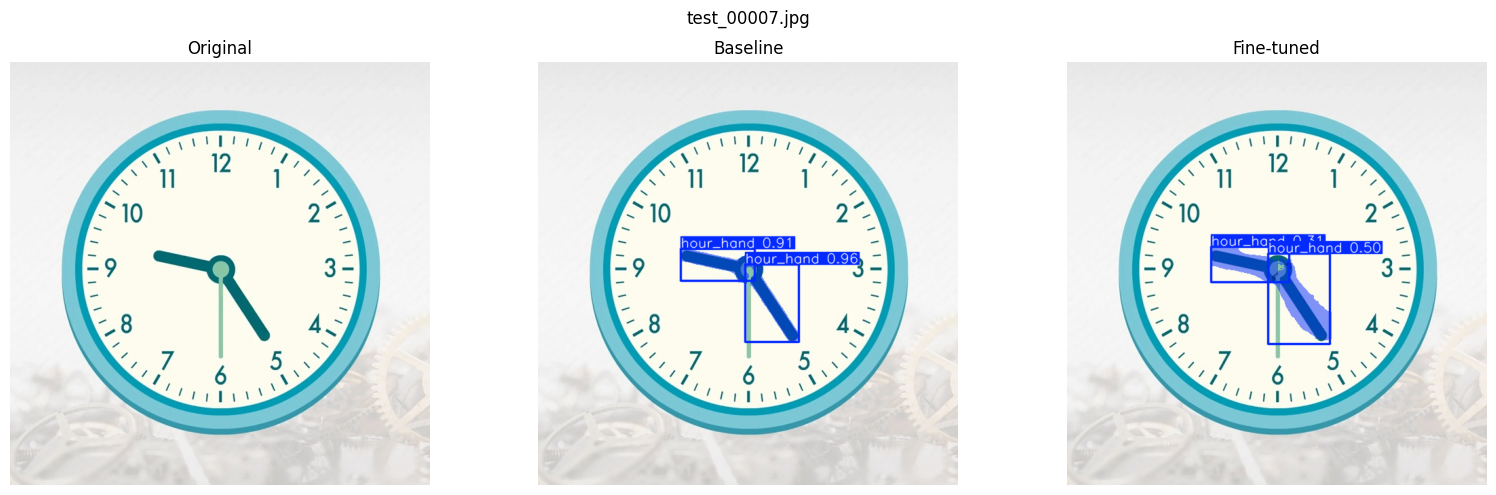

In [16]:
%matplotlib inline 

TEST_IMAGES = sorted((DATASET_DIR / "images" / "test").glob("*"))
NUM_TO_SHOW = min(8, len(TEST_IMAGES))
SAMPLE_TEST_IMAGES = TEST_IMAGES[:NUM_TO_SHOW]

print(f"Visualizing {len(SAMPLE_TEST_IMAGES)} test images")
show_predictions(base_model=base_model, tuned_model=tuned_model, image_paths=SAMPLE_TEST_IMAGES, conf=0.25)


In [ ]:
results_csv = TRAIN_RUN_DIR / "results.csv"
if results_csv.exists():
    history = pd.read_csv(results_csv)
    metric_cols = [
        c for c in [
            "metrics/mAP50(B)",
            "metrics/mAP50-95(B)",
            "metrics/mAP50(M)",
            "metrics/mAP50-95(M)",
        ] if c in history.columns
    ]
    if metric_cols:
        ax = history[metric_cols].plot(figsize=(9, 5), grid=True)
        ax.set_title("Validation mAP During Fine-tuning")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        plt.show()
    else:
        print("results.csv exists, but expected metric columns were not found")
        print("Columns:", list(history.columns))
else:
    print(f"results.csv not found at {results_csv}")
